In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils.plotting import *

In [2]:
rel_path = "/home/khain/FSNet/"
dir_path = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20260112-142011_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260112-141000_model_990/results.pkl"

results = load_results(rel_path + dir_path)

In [3]:
print(results['training_time_seconds'])
print("\n")
print(results['config'])

789.6153285503387


{'seed': 1, 'train_size': 7000, 'test_size': 2000, 'val_size': 1000, 'batch_size': 512, 'test_batch_size': [256, 512], 'eval_step': 10, 'hidden_dim': 1024, 'num_layers': 4, 'dropout': 0.1, 'penalty': {'obj_weight': 1.0, 'eq_pen_weight': 50.0, 'ineq_pen_weight': 50.0, 'lr': 0.0001, 'lr_decay': 0.9, 'lr_decay_step': 100, 'num_epochs': 500}, 'adaptive_penalty': {'obj_weight': 1.0, 'eq_pen_weight_max': 500.0, 'ineq_pen_weight_max': 100.0, 'eq_pen_weight': 30.0, 'ineq_pen_weight': 30.0, 'increasing_rate': 2.0}, 'FSNet': {'obj_weight': 1.0, 'dist_weight': 5.0, 'eq_pen_weight': 10.0, 'ineq_pen_weight': 10.0, 'val_tol': 1e-09, 'test_val_tol': 1e-09, 'decay_tol_step': 100, 'memory_size': 30, 'max_iter': 50, 'max_diff_iter': 30, 'scale': 1000, 'lr': 0.0001, 'lr_decay': 0.9, 'lr_decay_step': 100, 'num_epochs': 300}, 'sup': {'obj_weight': 1.0, 'eq_pen_weight': 10.0, 'ineq_pen_weight': 10.0, 'val_tol': 1e-07, 'test_val_tol': 1e-09, 'decay_tol_step': 100, 'memory_size': 30, 'max_

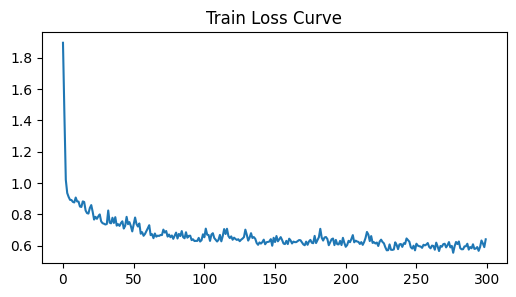

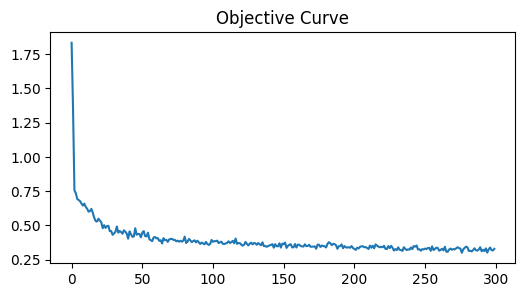

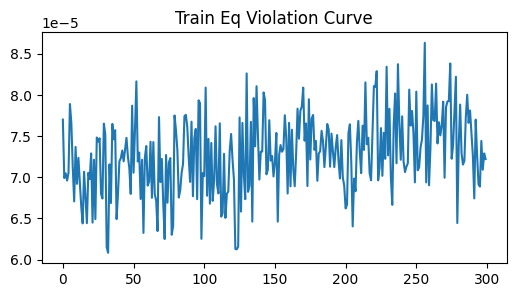

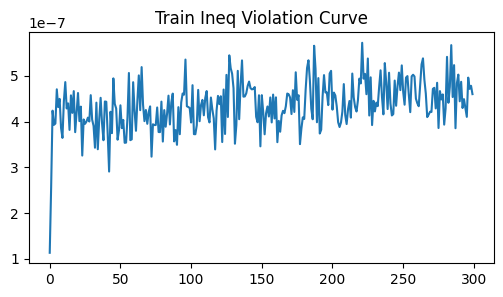

In [4]:
train_metrics = get_train_metrics(results)

start = 0
end = 1000

plt.figure(figsize=(6, 3))
plt.title('Train Loss Curve')
plt.plot(train_metrics['loss'][start:end], label='Train Loss')

plt.figure(figsize=(6, 3))
plt.title('Objective Curve')
plt.plot(train_metrics['obj'][start:end], label='Train Loss')

plt.figure(figsize=(6, 3))
plt.title('Train Eq Violation Curve')
plt.plot(train_metrics['eq_violation_l1'][start:end], label='Train Eq Violation')

plt.figure(figsize=(6, 3))
plt.title('Train Ineq Violation Curve')
plt.plot(train_metrics['ineq_violation_l1'][start:end], label='Train Ineq Violation')

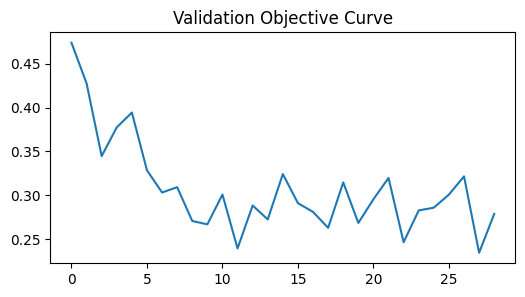

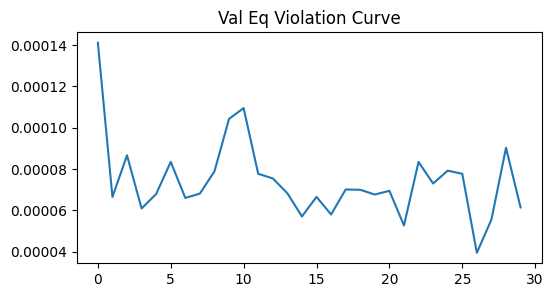

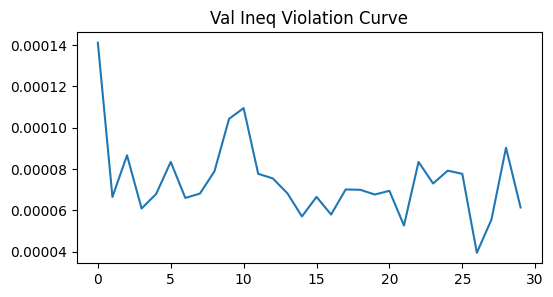

In [8]:
val_metrics = get_val_metrics(results)

plt.figure(figsize=(6, 3))
plt.title('Validation Objective Curve')
plt.plot(val_metrics['merit_mean'][1:], label='Val Objective')

# violation
plt.figure(figsize=(6, 3))
plt.title('Val Eq Violation Curve')
plt.plot(val_metrics['eq_violation_l1_mean'][start:end], label='Val Eq Violation')

plt.figure(figsize=(6, 3))
plt.title('Val Ineq Violation Curve')
plt.plot(val_metrics['eq_violation_l1_mean'][start:end], label='Val Ineq Violation')

In [ ]:
def get_train_metrics_stats(dir_path_seeds):
    num_seeds = len(dir_path_seeds)
    results = [load_results(rel_path + path) for path in dir_path_seeds]
    num_epoch = min([len(res['train_history']) for res in results])
    all_metrics = {
        key: np.zeros((num_seeds, num_epoch))
        for key in [
            'obj', 'loss',
            'eq_violation', 'ineq_violation',
            'eq_violation_l1', 'ineq_violation_l1',
            'distance'
        ]
    }
    for seed_idx, path in enumerate(dir_path_seeds):
        results = load_results(rel_path + path)
        train_metrics = get_train_metrics(results)
        for key in all_metrics.keys():
            all_metrics[key][seed_idx, :] = train_metrics[key][:num_epoch]

    mean_metrics = {key: np.mean(all_metrics[key], axis=0) for key in all_metrics.keys()}
    std_metrics = {key: np.std(all_metrics[key], axis=0) for key in all_metrics.keys()}
    return mean_metrics, std_metrics

def get_val_metrics_stats(dir_path_seeds):
    num_seeds = len(dir_path_seeds)
    results = [load_results(rel_path + path) for path in dir_path_seeds]
    num_evals = min([len(res['val_history']) for res in results])
    all_metrics = {
        key: np.zeros((num_seeds, num_evals))
        for key in [
            'objective', 'true_objective',
            'opt_gap_mean', 'opt_gap_std', 'opt_gap_max', 'opt_gap_min',
            'eq_violation_l2_mean', 'eq_violation_l2_max',
            'ineq_violation_l2_mean', 'ineq_violation_l2_max',
            'eq_violation_l1_mean', 'eq_violation_l1_max',
            'ineq_violation_l1_mean', 'ineq_violation_l1_max',
            'eq_violation_max_mean', 'eq_violation_max_max',
            'ineq_violation_max_mean', 'ineq_violation_max_max',
            'solution_distance_mean', 'solution_distance_std', 'solution_distance_max'
        ]
    }
    for seed_idx, path in enumerate(dir_path_seeds):
        results = load_results(rel_path + path)
        val_metrics = get_val_metrics(results)
        for key in all_metrics.keys():
            all_metrics[key][seed_idx, :] = val_metrics[key][:num_evals]

    mean_metrics = {key: np.mean(all_metrics[key], axis=0) for key in all_metrics.keys()}
    std_metrics = {key: np.std(all_metrics[key], axis=0) for key in all_metrics.keys()}
    return mean_metrics, std_metrics
    

In [ ]:
mean_metrics, std_metrics = get_val_metrics_stats(dir_path_seeds)
start_eval = 1
end_eval = 40
eval_range = range(start_eval, end_eval)
# mutiplie eval_range by eval_step
eval_step = 20
eval_range = [x * eval_step for x in eval_range]
for key in mean_metrics.keys():
    plt.figure()
    plt.title(f'Validation {key} Curve')
    plt.plot(eval_range, mean_metrics[key][start_eval:end_eval], label=f'Mean {key}')
    plt.fill_between(eval_range,
                     mean_metrics[key][start_eval:end_eval] - std_metrics[key][start_eval:end_eval],
                     mean_metrics[key][start_eval:end_eval] + std_metrics[key][start_eval:end_eval],
                     alpha=0.3, label=f'Std Dev {key}')
    plt.xlabel('Evaluation')
    plt.ylabel(key)
    plt.legend()
    plt.show()

NameError: name 'dir_path_seeds' is not defined

In [ ]:
rel_path = "/home/khain/FSNet/"
dir_path = "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000/20251106-163705_MLP_penalty_seed3_dropout0.1_finetune_20251031-073026_model_20/results.pkl"
# 20251105-161915_MLP_penalty_seed0_dropout0.1
# 20251105-154420_MLP_DC3_seed0_dropout0.1
results = load_results(rel_path + dir_path)

# Get batch comparison data from the loaded results
batch_comparison = results['test_results']['batch_size_comparison']

# Create a more readable DataFrame by expanding the metrics
readable_data = []
for batch_size, data in batch_comparison.items():
    metrics = data['metrics']
    row = {
        'Batch Size': batch_size,
        'Opt Gap Mean': f"{metrics['opt_gap_mean']:.4f}",
        'Opt Gap Std': f"{metrics['opt_gap_std']:.4f}",
        'Opt Gap Max': f"{metrics['opt_gap_max']:.4f}",
        'Eq Violation Mean': f"{metrics['eq_violation_l1_mean']:.2e}",
        'Eq Violation Max': f"{metrics['eq_violation_l1_max']:.2e}",
        'Ineq Violation Mean': f"{metrics['ineq_violation_l1_mean']:.2e}",
        'Ineq Violation Max': f"{metrics['ineq_violation_l1_max']:.2e}",
        'Average Batch Time (s)': f"{metrics['avg_inference_time']:.4f}",
    }
    readable_data.append(row)

df_readable = pd.DataFrame(readable_data)
df_readable_styled = df_readable.style.set_properties(**{'text-align': 'center'})
display(df_readable_styled)

,Batch Size,Opt Gap Mean,Opt Gap Std,Opt Gap Max,Eq Violation Mean,Eq Violation Max,Ineq Violation Mean,Ineq Violation Max,Average Batch Time (s)
0,256,-2.3001,1.1457,2.9377,3.23e-01,5.42e-01,3.10e-02,6.50e-01,0.0002
1,512,-2.3417,0.6926,4.5516,3.23e-01,5.85e-01,3.11e-02,7.45e-01,0.0002
